# E-commerce Sales, Inventory, and Customer Analysis

This notebook is a portfolio-style business analysis project designed to reflect the kind of work a data analysis intern might do for a direct-to-consumer brand.

## Questions answered

- How is revenue changing over time?
- Which categories and channels drive the most revenue?
- How important are repeat customers?
- Where do we see low-stock risk?


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[0]
DATA_PATH = ROOT / "data" / "raw_data.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Order ID,Order Date,Customer ID,Customer Segment,Sales Channel,Region,Product ID,Category,Product Name,Unit Price,Quantity,Discount Pct,Revenue,Inventory On Hand,Reorder Level
0,O50000,2025-03-08,C10394,Repeat,Organic Search,West,P1000,Tops,Classic Tee,78.0,1,0.20,62.4,244.0,49
1,O50001,2025-05-15,C10326,Repeat,Email Campaign,Northeast,P1001,Tops,Air Tunic,62.0,1,0.20,49.6,163.0,72
2,O50002,2025-08-15,C10082,Repeat,Mobile App,Northeast,P1008,Outerwear,Transit Coat,218.0,1,0.00,218.0,414.0,47
3,O50003,2025-12-28,C10282,New,Paid Social,West,P1002,Tops,Everyday Shirt,71.0,1,0.05,67.45,238.0,67
4,O50003,2025-12-28,C10282,New,Paid Social,West,P1000,Tops,Classic Tee,78.0,1,0.10,70.2,243.0,49


## Clean the data

In [2]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
df["order_date"] = pd.to_datetime(df["order_date"])
df["sales_channel"] = df["sales_channel"].str.title()
df["category"] = df["category"].str.title()
df["revenue"] = (
    df["revenue"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["discount_pct"] = df["discount_pct"].fillna(0)
df["region"] = df["region"].fillna("Unknown")
df["inventory_on_hand"] = df["inventory_on_hand"].fillna(df["reorder_level"])

df["inventory_status"] = df.apply(
    lambda row: "Low Stock Risk"
    if row["inventory_on_hand"] <= row["reorder_level"] * 1.2
    else "Healthy",
    axis=1,
)
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["first_purchase_date"] = df.groupby("customer_id")["order_date"].transform("min")
df["customer_tenure_days"] = (df["order_date"] - df["first_purchase_date"]).dt.days
df["is_repeat_customer"] = df["customer_tenure_days"] > 0
df["avg_unit_revenue"] = (df["revenue"] / df["quantity"]).round(2)

df.head()

,order_id,order_date,customer_id,customer_segment,sales_channel,region,product_id,category,product_name,unit_price,quantity,discount_pct,revenue,inventory_on_hand,reorder_level,inventory_status,month,first_purchase_date,customer_tenure_days,is_repeat_customer,avg_unit_revenue
0,O50000,2025-03-08,C10394,Repeat,Organic Search,West,P1000,Tops,Classic Tee,78.0,1,0.20,62.40,244.0,49,Healthy,2025-03,2025-03-08,0,False,62.40
1,O50001,2025-05-15,C10326,Repeat,Email Campaign,Northeast,P1001,Tops,Air Tunic,62.0,1,0.20,49.60,163.0,72,Healthy,2025-05,2025-04-30,15,True,49.60
2,O50002,2025-08-15,C10082,Repeat,Mobile App,Northeast,P1008,Outerwear,Transit Coat,218.0,1,0.00,218.00,414.0,47,Healthy,2025-08,2025-06-15,61,True,218.00
3,O50003,2025-12-28,C10282,New,Paid Social,West,P1002,Tops,Everyday Shirt,71.0,1,0.05,67.45,238.0,67,Healthy,2025-12,2025-02-08,323,True,67.45
4,O50003,2025-12-28,C10282,New,Paid Social,West,P1000,Tops,Classic Tee,78.0,1,0.10,70.20,243.0,49,Healthy,2025-12,2025-02-08,323,True,70.20


## KPI summary

In [3]:
total_revenue = df["revenue"].sum()
total_orders = df["order_id"].nunique()
total_units = df["quantity"].sum()
average_order_value = df.groupby("order_id")["revenue"].sum().mean()
repeat_revenue_share = (
    df.groupby("order_id")
      .agg(revenue=("revenue","sum"), is_repeat=("is_repeat_customer","max"))
)
repeat_revenue_share = repeat_revenue_share.loc[repeat_revenue_share["is_repeat"], "revenue"].sum() / df.groupby("order_id")["revenue"].sum().sum()

kpis = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Orders", "Units Sold", "Average Order Value", "Repeat Revenue Share"],
    "Value": [round(total_revenue, 2), total_orders, total_units, round(average_order_value, 2), round(repeat_revenue_share * 100, 1)]
})
kpis

,Metric,Value
0,Total Revenue,342950.85
1,Total Orders,1250.00
2,Units Sold,2966.00
3,Average Order Value,274.36
4,Repeat Revenue Share,68.00


## Revenue over time

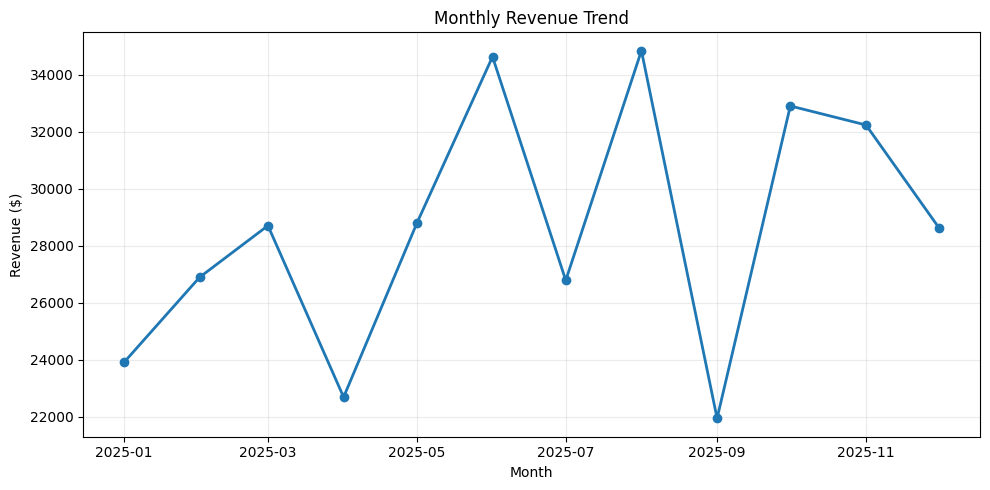

In [4]:
monthly = df.groupby("month", as_index=False).agg(
    revenue=("revenue", "sum"),
    orders=("order_id", "nunique"),
    units=("quantity", "sum"),
)

plt.figure(figsize=(10, 5))
plt.plot(pd.to_datetime(monthly["month"]), monthly["revenue"], marker="o", linewidth=2)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Revenue by category

In [5]:
category_revenue = (
    df.groupby("category", as_index=False)
      .agg(revenue=("revenue", "sum"))
      .sort_values("revenue", ascending=False)
)
category_revenue

,category,revenue
3,Outerwear,103930.25
1,Dresses,89124.53
0,Bottoms,56889.30
2,Loungewear,55260.32
4,Tops,37746.45


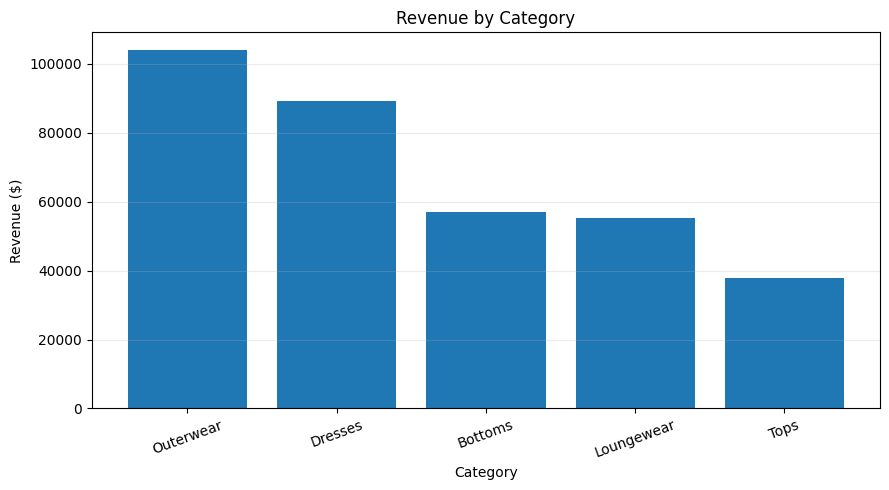

In [6]:
plt.figure(figsize=(9, 5))
plt.bar(category_revenue["category"], category_revenue["revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Revenue by channel

In [7]:
channel_revenue = (
    df.groupby("sales_channel", as_index=False)
      .agg(revenue=("revenue", "sum"))
      .sort_values("revenue", ascending=False)
)
channel_revenue

,sales_channel,revenue
4,Web,115464.04
1,Mobile App,80478.33
2,Organic Search,54585.28
3,Paid Social,53067.36
0,Email Campaign,39355.84


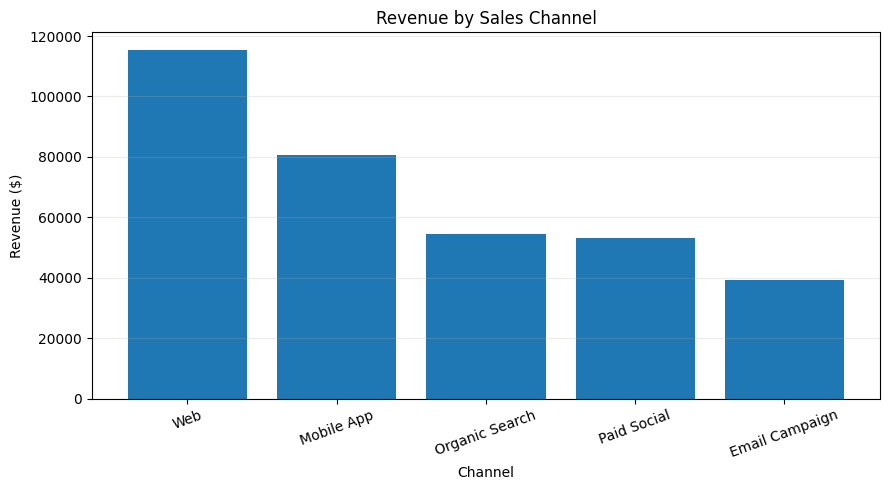

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(channel_revenue["sales_channel"], channel_revenue["revenue"])
plt.title("Revenue by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Repeat customer trend

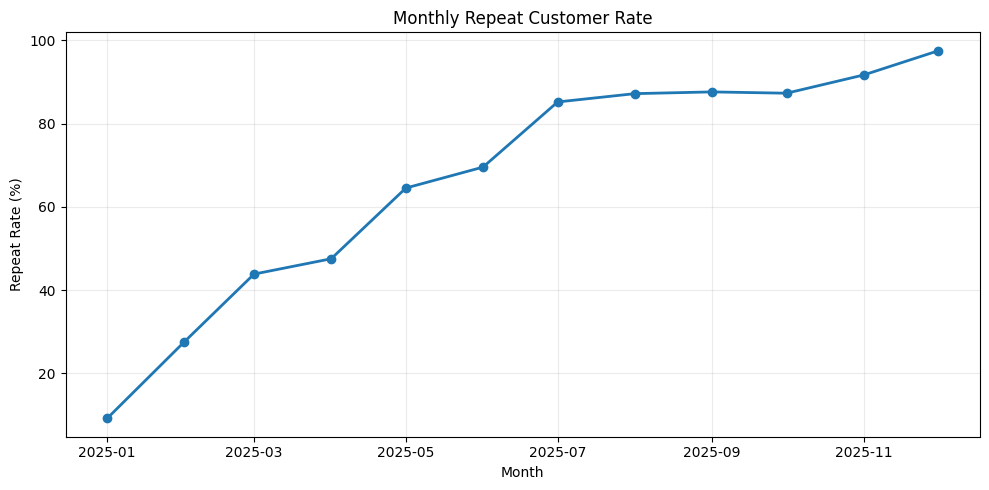

In [9]:
repeat_rate = (
    df.groupby("month")["is_repeat_customer"]
      .mean()
      .reset_index(name="repeat_rate")
)

plt.figure(figsize=(10, 5))
plt.plot(pd.to_datetime(repeat_rate["month"]), repeat_rate["repeat_rate"] * 100, marker="o", linewidth=2)
plt.title("Monthly Repeat Customer Rate")
plt.xlabel("Month")
plt.ylabel("Repeat Rate (%)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Inventory status

In [10]:
inventory_status = (
    df.groupby(["category", "inventory_status"])
      .size()
      .unstack(fill_value=0)
)
inventory_status

inventory_status,Healthy,Low Stock Risk
category,,
Bottoms,355,11
Dresses,373,20
Loungewear,380,11
Outerwear,349,1
Tops,337,25


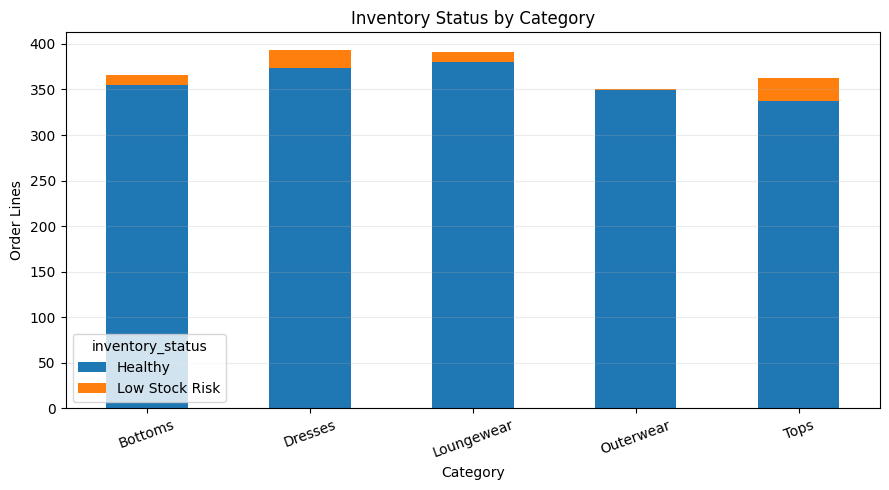

In [11]:
inventory_status.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Inventory Status by Category")
plt.xlabel("Category")
plt.ylabel("Order Lines")
plt.xticks(rotation=20)
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Business recommendations

1. Prioritize inventory planning for high-revenue categories such as Outerwear and Dresses.
2. Treat repeat customers as a major revenue driver and support retention with targeted campaigns.
3. Use channel-level reporting to guide budget allocation across Web, Mobile App, and acquisition channels.
4. Track low-stock-risk products earlier to reduce lost sales opportunities.
